# DBSCAN

*Density-Based Spatial Clustering of Applications with Noise*. Algoritmo di clustering basato su densità.

M.Ester, H.Kriegel, J.Sander, X.Xu. *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*. 1996.

Parametri:

- `min_pts`: numero minimo di punti per formare un cluster
- `eps`: distanza massima affinché due punti siano considerati vicini.

Numero di cluster non fissato a priori, viene deciso dall'algoritmo.

## Definizioni

- *Core point*: un punto che ha almeno `min_pts` in un suo intorno `eps`.
- *Border point*: un punto non core ma che è vicino ad un core
- *Noise point*: nè core, nè border

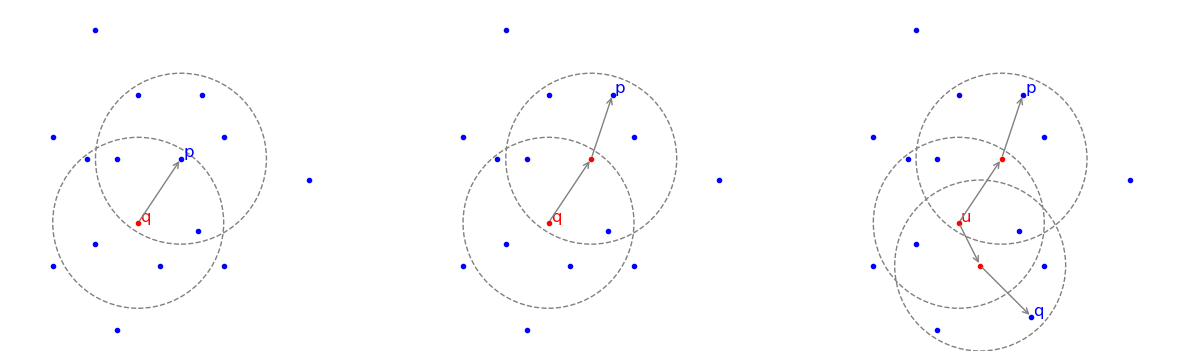


### Raggiungibilià

- Un punto `p` è *raggiungibile direttamente per densità* da `q` se `q` è un core e `p` è nel suo vicinato (fugura a sinistra). *In questo caso `q` appartiene ad un cluster*.
- Un punto `p` è *raggiungibile per densità* da `q` se esiste una catena di punti core a partire da `q` ciascuno raggiungibile direttamente per densità dal precedente (nella figura al centro, la catena contiene solo due punti core). *In questo caso tutti i core della catena sono punti di un unico cluster.*
- I punti `p` e `q` sono *connessi per densità*  se esiste un punto `u` da cu `p` e `q` sono raggiungibili per densità (figura a destra).

## Cluster

`C` è un cluster, rispetto `min_pts` e `eps` se è non vuoto e soddisfa le seguenti proprietà:
- Per ogni coppia `p` e `q`, se `q` è in `C` e `p` è raggiungibile per densità da `q`, anche `p` appartiene a `C`.
- Ogni coppia `p` e `q` in `C` deve essere connessa per densità. (Ovvero solo i punti raggiungibili per densità da un core in `C` sono in `C`)

Dalla definizione, i border possono appartenere a più cluster perché raggiungibili per densità da più core non vicini. L'algoritmo ne sceglierà uno e sarà il primo da cui viene raggiunto.

## L'Algoritmo

- INPUT: un insieme `D` di `n` punti, `eps`, `min_pts`
- OUTPUT: per ogni punto `p` in `D`, un valore `label[p]` in `{Noise, 0, 1, ...}`

* Inizializzazione: `label[p] ← non_visitato` per tutti i punti `p`
* Per ogni punto `p` in `D` etichettato `non_visitato`:
    1. Sia `N` l'insieme dei punti a distanza `≤ eps` da `p`
    2. Se `|N| < min_pts`, non è un core point, ma potrebbe diventare border. Per il momento
        - `label[p] ← Noise`
    3. Altrimenti `p` è un core di un nuovo cluster `c`, quindi
        * `label[p] ← c`
        * `S ← N - {p}`
        * Prosegui prelevando punti `q` da `S` fino ad esaurimento di quest'ultimo
            - Se `q` è già in un cluster, scartalo (se `label[q]` è un numero)
            - `label[q] ← c` anche se valeva `Noise`
            - Se `q` è un core point
                - Definisci `N` come l'insieme dei vicini di `q`
                - `S ← S ∪ (N - {q})`

## Implementazione

Un dataset per cominciare

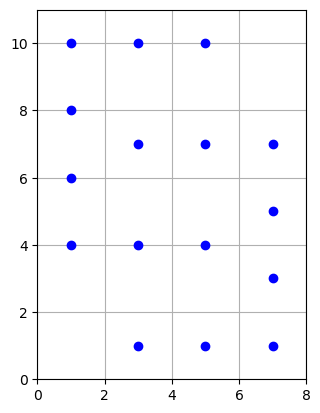

In [2]:
import matplotlib.pyplot as plt
import numpy as np

points =  [(3,1), (5,1), (7,1), (7,3), (7,5), (7,7), (5,7), (3,7),
           (5,4), (3,4), (1,4), (1,6), (1,8), (1,10), (3,10), (5,10)]

fig, ax = plt.subplots(1, 1)

ax.scatter([x for x, _ in points], [y for _, y in points], color='blue', marker='o', zorder=3)

ax.set_xlim(0, 8)
ax.set_ylim(0, 11)
ax.set_aspect('equal')
ax.grid(True)
#ax.axis('off')
plt.show()

In [3]:
from scipy.spatial import KDTree

def dbscan(points, eps, min_pts):
    '''
    points: Una sequenza di punti, o qualsiasi struttura che possa essere interpretata coma una sequenza di punti
    eps: distanza massima per essere considerato vicino
    min_pts: numero di punti minimo di vicini per essere considerato core

    Ritorna una lista label tale che labels[i] in ('Noise', '0', '1', '2', '3',...) e descrive il cluster a cui appartiene il points[i]
    '''
    points = np.array(points)

    n = points.shape[0]
    tree = KDTree(points)

    c = -1  # c+1 sarà il 'nome' del prossimo cluster
    labels = [None]*n # non visitato

    for i, p in enumerate(points):
        if labels[i] != None:
            continue
        N = tree.query_ball_point(p, eps) # indici in points dei punti a distanza eps da p
        if len(N) < min_pts:
            labels[i] = 'Noise'
            continue

        c += 1

        labels[i] = str(c)

        # estensione
        S = set(N) - set([i]) # nel caso medio |N| è considerato costante
        while len(S) > 0:
            j = S.pop()
            if labels[j] == 'Noise': # non core
                labels[j] = str(c)
            if labels[j] != None: # non core, altrimenti i nel cluster
                continue
            labels[j] = str(c)
            N = tree.query_ball_point(points[j], eps)
            if len(N) < min_pts:
                continue
            S.update( set(N) - set([j]) )

    return labels



**Esercizio 1**. Stimare la complessità temporale dell'algoritmo.

Esecuzione dell'algoritmo su l'istanza illustrata sopra.

In [4]:
labels = dbscan(points, eps=2, min_pts=2)
print(labels)

['0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '1', '1']


Rappresentiamo la soluzione graficamente definendo un array di colori per le due classi: `'blue'` per `'0'`, `'red'` per `'1'`.

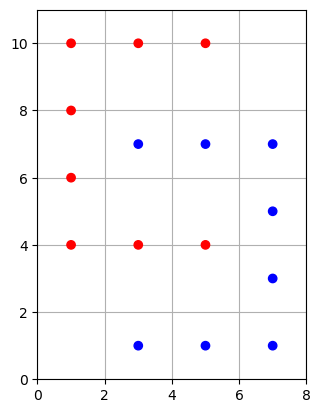

In [5]:
points =  [(3,1), (5,1), (7,1), (7,3), (7,5), (7,7), (5,7), (3,7),
           (5,4), (3,4), (1,4), (1,6), (1,8), (1,10), (3,10), (5,10)]

fig, ax = plt.subplots(1, 1)


ax.scatter([x for x, _ in points], [y for _, y in points], color= ['blue' if v == '0' else 'red' for v in labels], marker='o', zorder=3)

ax.set_xlim(0, 8)
ax.set_ylim(0, 11)
ax.set_aspect('equal')
ax.grid(True)
#ax.axis('off')
plt.show()

Dataset random

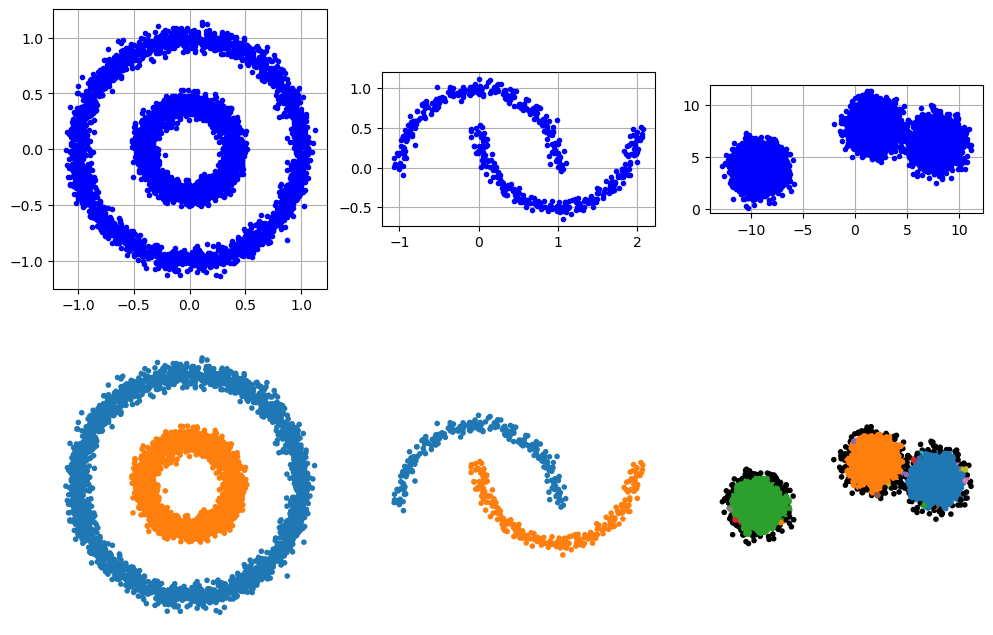

In [7]:
from sklearn import datasets
import matplotlib.colors as mcolors

# con scikit posso generare: cerchi concentrici, mezzelune, blob di punti
noisy_circles = datasets.make_circles(n_samples=5000, factor=0.4, noise=0.05, random_state=0)
noisy_moons = datasets.make_moons(n_samples=500, noise=0.05, random_state=0)
blobs = datasets.make_blobs(n_samples=15000, center_box=(-10,10), random_state=20)

# crea una matrice 2x3 di plot da visualizzare
fig, axs = plt.subplots(2, 3, figsize=(12,8))

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    ax = axs[0][i] # iteriamo sulla prima riga di grafici
    ax.scatter([x for x, _ in points], [y for _, y in points], color= 'blue', marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    #ax.axis('off')

color_map = list(mcolors.TABLEAU_COLORS.keys())*10

for i, the_dataset in enumerate([noisy_circles, noisy_moons, blobs]): 
    points = the_dataset[0]
    labels = dbscan(points, eps=0.2, min_pts=4)
    ax = axs[1][i] # iteriamo sulla seconda riga
    colors = []
    for lab in labels:
        # il noise e nero
        if lab == 'Noise':
            colors.append('black')
        else:
            colors.append(color_map[int(lab)])
    ax.scatter([x for x, _ in points], [y for _, y in points], color=colors, marker='.', zorder=3)
    ax.grid(True)
    ax.set_aspect('equal')
    ax.axis('off')

## Stima del parametro `eps`

Per stimare il valore ottimale di `eps`, a ogni punto `p` si associa la distanza dal punto più lontano tra i suoi `min_pts` vicini. Le distanze così ottenute vengono ordinate in ordine crescente, ottenendo una curva che cresce lentamente all’inizio e poi aumenta bruscamente.

![gomito](09-01-gomito.png)

I punti situati in zone dense presentano distanze piccole, mentre quelli in zone più isolate hanno distanze maggiori. Il punto in cui la curva cambia nettamente, il cosiddetto *gomito*, indica il confine tra zone dense e rumore. Il valore della distanza in prossimità del gomito rappresenta un buon candidato per `eps`.

Per individuarlo automaticamente, si cerca il punto della curva che ha la massima distanza dalla retta che unisce gli estremi sinistro e destro della curva, corrispondenti ai punti `A` e `B` nella figura.

**Esercizio 1**: quanto costa `dbscan`? 

**Esercizio 2**. Si utilizzi il metodo descritto per trovare il valore di `eps` consigliato per i tre dataset dell'esempio precedente.